In [1]:
pip install ProcessOptimizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.9 MB/s eta 0:00:00


In [49]:
import torch
import numpy as np

from typing import List, Optional, Union
# from .model_system import ModelSystem
# from ..space import Real
from ProcessOptimizer.model_systems import ModelSystem
from ProcessOptimizer.space import Real


class GPExperiment:
    """Base Class for 1D Gaussian Process experiment."""
    def __init__(
            self,
            lower_bound: Optional[float],
            upper_bound: Optional[float],
            grid: Optional[int],
            tasks: Optional[int],
            signal_variance: Optional[float],
            lengthscale: Optional[float],
            seed: Optional[int] = 42,
    ):
        """
        Parameters
        ----------
        *  'lower_bound' [Optional[float]]:
            lower bound of 1D domain of Gaussian Process.
        * 'upper_bound' [Optional[float]]:
            upper bound of 1D domain of Gaussian Process.
        * 'tasks' [Optional[int]]:
            number of tasks generated from GP
        * 'seed' [Optional[int], default=42]:
            seed for numpy random number generator
        """
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.grid = grid
        self.tasks = tasks
        self.signal_variance = signal_variance
        self.lengthscale = lengthscale
        self._rng = np.random.RandomState(seed)
        self.experiment = self._initiate_experiment()

    def get_domain(self, gridsize, tolist=False)-> Union[torch.Tensor, List[Real]]:
        """Generates the domain of the Gaussian Process
        Parameters
        ----------
        * `gridsize` [int]:
            Number of grid points.
        * `tolist` [bool]:
            Whether to return the domain as a list.

        Returns
        -------
        * `domain` Union[torch.Tensor, List[Real]]:
            The domain of the Gaussian Process used by GP score.
        """
        domain = torch.linspace(self.lower_bound,self. upper_bound, gridsize)
        if tolist:
            return domain.tolist()
        else:
            return domain
    def _get_exp_kernel(self, signal_variance, lengthscale):
        "RBF kernel for Gaussian Process."
        return lambda a, b: signal_variance * (
                    -0.5 * (a.reshape(-1, 1) - b.reshape(1, -1)).pow(2) / (lengthscale ** 2)).exp()

    def _sample_from_gp(self, domain, kernel) -> torch.Tensor:
        """
         Sample trajectories of the Gaussian Process.
         The total number of trajectories is equal to number of tasks.
        """
        K = kernel(domain, domain)
        # sample from N(0, K):
        # L: LL' = K
        # f = L @ z, z ~ N(0, I)
        d, V = torch.linalg.eigh(K)  # computes the eigenvalue decomposition, d - eig values, V - eigen vectors
        L = d.clamp_min(0.0).sqrt() * V
        f = L @ torch.randn(L.shape[0], self.tasks)
        return f.squeeze()
    def _initiate_experiment(self):
        domain = self.get_domain(self.grid)
        task_values = self._sample_from_gp(domain, kernel=self._get_exp_kernel(self.signal_variance, self.lengthscale))
        experiment = {'domain': domain, 'f_values': task_values}
        return experiment

    def score(self, x, idx):
        if self.experiment['domain'][idx] == x:
            return self.experiment['f_values'][idx]
        else:
            print('not found')
            # TODO: raise error

    def get_sample(self, size, noise_scale=0.1):
        indices = np.random.choice(range(self.experiment['domain'].shape[0]), size, replace=False)
        x = torch.Tensor(self.experiment['domain'][indices])
        y = torch.Tensor( self.experiment['f_values'][indices,:]) + noise_scale * torch.randn(
            self.experiment['f_values'][indices,:].size())  # sigma * N(0, 1) + m = N(m, sigma^2)
        return indices, x, y

    @property
    def max(self):
        return self.experiment['f_values'].max(0)
    @property
    def min(self):
        return self.experiment['f_values'].min(0)

def create_gp_experiment(lower_bound, upper_bound, tasks, signal_variance, lengthscale, grid=100) -> ModelSystem:
    gp_experiment = GPExperiment(lower_bound, upper_bound, grid, tasks, signal_variance, lengthscale)
    return ModelSystem(
        gp_experiment.score,
        [Real(lower_bound, upper_bound, name='domain')],
        noise_model=None,
        true_max=gp_experiment.max,
        true_min=gp_experiment.min)

**GP Experiment Model System** samples from the Gausian Process with RGB kernel and simulates 'the true unknown system'. Assume that the data from the lab experiments come from the distribution of Gaussian Process. The realised trajectory corresponds to one expriment. Even if the data from different laboratory settings differ, in this simlified setup we assume that the generative model for the lab experiments is driven by Gaussian distribution over given domain.

*  'lower_bound' [Optional[float]]:
    lower bound of 1D domain of Gaussian Process.
*  'upper_bound' [Optional[float]]:
    upper bound of 1D domain of Gaussian Process.
*  'grid': Optional[int]:
*  'tasks' [Optional[int]]:
    number of tasks generated from GP
* 'signal_variance': Optional[float]
* 'lengthscale': Optional[float]
* 'seed' [Optional[int], default=42]:
    seed for numpy random number generator
     

**Example**

We collect 10 measurements from the 4 experiments with features taking values on the domain [-1.5, 1.5]. The underlying generative process of these data is Gaussian process with RBF with lengthscale 0.5 and signal variance 1.5.

In [56]:
gp1 = GPExperiment(-1.5, 1.5, 100, 4, 1.5, 0.5)

idx, train_x, train_y = gp1.get_sample(10)

print(gp1.score(exp1[0], 0))

print(gp1.max)
create_gp_experiment(-1.5, 1.5, 4, 1.5, 0.5)

tensor([ 0.7617,  0.7456,  0.5736, -1.0998])
torch.return_types.max(
values=tensor([1.9177, 1.5015, 3.6884, 0.4415]),
indices=tensor([98, 99, 80, 81]))


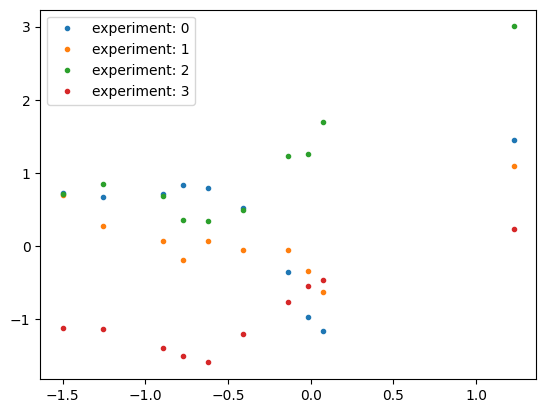

In [57]:
from matplotlib import pyplot as plt

for idx_ in range(train_y.shape[1]):
  plt.plot(train_x, train_y[:, idx_], '.', label='experiment: %s'%(idx_));

plt.legend();